In [1]:
# Convolutional vision transformer

In [2]:
#importing
import os
import math
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [3]:
#gpu
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Device:", device)

Device: cuda


In [4]:
IMAGE_SIZE = 224
NUM_CLASSES = 6
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.05
DROP_RATE = 0.1
DROP_PATH_RATE = 0.1
# Stage configuration
EMBED_DIMS = [64, 192, 384]
DEPTHS = [1, 2, 4]
NUM_HEADS = [1, 3, 6]
MLP_RATIOS = [4, 4, 4]
#embed_dims/num_heads = 64 for all 3 layers, so 64 dimensions for each attn head
#each layer grows from 64 to 384 unlike 384 to 384 in ViT

In [5]:
#check for dataset paths to split dataset etc
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/puneet6060
/kaggle/input/datasets/puneet6060/intel-image-classification
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/street
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/buildings
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/sea
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/forest
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/glacier
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_pred
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_pred/seg_pred
/kaggle/input/datasets/puneet6060/in

In [6]:
#std kaggle path test
DATASET_ROOT = "/kaggle/input/datasets/puneet6060/intel-image-classification"
TRAIN_DIR = os.path.join(
    DATASET_ROOT,
    "seg_train",
    "seg_train"
)
TEST_DIR = os.path.join(
    DATASET_ROOT,
    "seg_test",
    "seg_test"
)
print("Train:", TRAIN_DIR)
print("Test :", TEST_DIR)
print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test exists :", os.path.exists(TEST_DIR))

Train: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train
Test : /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test
Train exists: True
Test exists : True


In [7]:
full_train_dataset = datasets.ImageFolder(
    TRAIN_DIR
)
print("Total training images:", len(full_train_dataset))
print("Classes:", full_train_dataset.classes)
print("Class mapping:", full_train_dataset.class_to_idx)

Total training images: 14034
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Class mapping: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


In [8]:
#dataset preprocessing
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.8, 1.0)
    ),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225] #doubt point
    )
])

In [9]:
#tester for transforms
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [10]:
#test,train,split
from torch.utils.data import random_split
train_dataset_full = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)
val_dataset_full = datasets.ImageFolder(
    TRAIN_DIR,
    transform=eval_transform
)
dataset_size = len(train_dataset_full)
indices = torch.randperm(
    dataset_size,
    generator=torch.Generator().manual_seed(42)
).tolist()
split = int(
    0.9 * dataset_size
)
train_indices = indices[:split]
val_indices = indices[split:]
from torch.utils.data import Subset
train_dataset = Subset(
    train_dataset_full,
    train_indices
)
val_dataset = Subset(
    val_dataset_full,
    val_indices
)
test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=eval_transform
)
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Training images: 12630
Validation images: 1404


In [11]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)
test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=eval_transform
)

In [12]:
#loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [13]:
#sanity check
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))
images, labels = next(iter(train_loader))
print("\nBatch image shape:", images.shape)
print("Batch label shape:", labels.shape)
print("Image dtype:", images.dtype)
print(
    "Classes:",
    train_dataset_full.classes
)

Train: 14034
Validation: 1404
Test: 3000

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Image dtype: torch.float32
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [14]:
#Conv token embedding
class ConvTokenEmbedding(nn.Module):
    def __init__(
        self,
        in_channels,
        embed_dim,
        kernel_size,
        stride,
        padding
    ):
        super().__init__()
        self.proj = nn.Conv2d(
            in_channels=in_channels,
            out_channels=embed_dim,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding
        )
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x):
        x = self.proj(x)
        x = x.permute(0, 2, 3, 1)
        x = self.norm(x)
        x = x.permute(0, 3, 1, 2)
        return x

In [15]:
#testcode
test_embedding = ConvTokenEmbedding(
    in_channels=3,
    embed_dim=64,
    kernel_size=7,
    stride=4,
    padding=2
).to(device)
dummy = torch.randn(
    2, 3, 224, 224,
    device=device
)
out = test_embedding(dummy)
print(out.shape)

torch.Size([2, 64, 56, 56])


In [16]:
#conv qkv projection
class ConvProjection(nn.Module):
    def __init__(
        self,
        dim,
        kernel_size=3,
        stride=1,
        padding=1
    ):
        super().__init__()
        self.depthwise = nn.Conv2d(
            dim,
            dim,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            groups=dim,
            bias=False
        )
        self.bn = nn.BatchNorm2d(dim)
    def forward(self, x):
        x = self.depthwise(x)
        x = self.bn(x)
        return x

In [17]:
#convolutional multiheadself attn
class ConvMultiHeadSelfAttention(nn.Module):
    def __init__(
        self,
        embed_dim,
        num_heads,
        dropout=0.1,
        kv_stride=2
    ):
        super().__init__()
        assert embed_dim % num_heads == 0, \
            "embed_dim must be divisible by num_heads" #error thrown if combination becomes float
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5
        # Q keeps the original spatial resolution
        self.q_conv = ConvProjection(
            dim=embed_dim,
            kernel_size=3,
            stride=1,
            padding=1
        )
        # K and V are spatially downsampled
        self.k_conv = ConvProjection(
            dim=embed_dim,
            kernel_size=3,
            stride=kv_stride,
            padding=1
        )
        self.v_conv = ConvProjection(
            dim=embed_dim,
            kernel_size=3,
            stride=kv_stride,
            padding=1
        )
        # Channel projections
        self.q = nn.Linear(embed_dim, embed_dim)
        self.k = nn.Linear(embed_dim, embed_dim)
        self.v = nn.Linear(embed_dim, embed_dim)
        self.proj = nn.Linear(
            embed_dim,
            embed_dim
        )
        self.attn_dropout = nn.Dropout(dropout)
        self.proj_dropout = nn.Dropout(dropout)
        # Used later for visualization
        self.last_attention = None
    def forward(self, x):
        B, C, H, W = x.shape
        #conv qkv projections
        q = self.q_conv(x)
        k = self.k_conv(x)
        v = self.v_conv(x)
        # Save Q spatial size because output must return to the original feature-map size
        Hq, Wq = q.shape[2], q.shape[3]
        #convert feature maps to tokens 
        q = q.flatten(2).transpose(1, 2)
        k = k.flatten(2).transpose(1, 2)
        v = v.flatten(2).transpose(1, 2)
        # Shapes: (B, N(i)c, C)
        # i = qkv based on which tensor
        #linear transformation (final)
        q = self.q(q)
        k = self.k(k)
        v = self.v(v)
        Nq = q.shape[1]
        Nk = k.shape[1]
        #splitting to heads
        q = q.reshape(
            B,
            Nq,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)
        k = k.reshape(
            B,
            Nk,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)
        v = v.reshape(
            B,
            Nk,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)
        # New shaps: (B, heads, N(i), head dimension)
        #attne calculation qk(t) 
        attn = (
            q @ k.transpose(-2, -1)
        ) * self.scale
        # (B, heads, Nq, Nk)
        attn = attn.softmax(dim=-1)
        self.last_attention = attn.detach()
        attn = self.attn_dropout(attn)
        #weighten sum 
        x = attn @ v
        # (B, heads, Nq, head_dim)
        # merging
        x = x.transpose(1, 2).reshape(
            B,
            Nq,
            C
        )
        x = self.proj(x)
        x = self.proj_dropout(x)
        #tokens to spatial feature maps
        x = x.transpose(1, 2).reshape(
            B,
            C,
            Hq,
            Wq
        )
        return x

In [18]:
#test
test_attn = ConvMultiHeadSelfAttention(
    embed_dim=64,
    num_heads=1,
    dropout=0.1,
    kv_stride=2
).to(device)
dummy = torch.randn(
    2,
    64,
    56,
    56
).to(device)
with torch.no_grad():
    output = test_attn(dummy)
print("Input shape :", dummy.shape)
print("Output shape:", output.shape)
print(
    "Attention shape:",
    test_attn.last_attention.shape
)

Input shape : torch.Size([2, 64, 56, 56])
Output shape: torch.Size([2, 64, 56, 56])
Attention shape: torch.Size([2, 1, 3136, 784])


In [19]:
#MLP 
class MLP(nn.Module):
    def __init__(
        self,
        embed_dim,
        mlp_ratio=4,
        dropout=0.1
    ):
        super().__init__()
        hidden_dim = int(
            embed_dim * mlp_ratio
        )
        self.fc1 = nn.Linear(
            embed_dim,
            hidden_dim
        )
        self.act = nn.GELU()
        self.dropout1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(
            hidden_dim,
            embed_dim
        )
        self.dropout2 = nn.Dropout(dropout)
    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.dropout2(x)
        return x

In [20]:
#tester for MLP
test_mlp = MLP(
    embed_dim=64,
    mlp_ratio=4,
    dropout=0.1
).to(device)
dummy = torch.randn(
    2,
    56,
    56,
    64
).to(device)
with torch.no_grad():
    output = test_mlp(dummy)
print("Input :", dummy.shape)
print("Output:", output.shape)

Input : torch.Size([2, 56, 56, 64])
Output: torch.Size([2, 56, 56, 64])


In [21]:
class DropPath(nn.Module):
    def __init__(
        self,
        drop_prob=0.0
    ):
        super().__init__()

        self.drop_prob = drop_prob
    def forward(self, x):
        if (
            self.drop_prob == 0.0
            or not self.training
        ):
            return x
        keep_prob = 1.0 - self.drop_prob
        shape = (
            x.shape[0],
        ) + (1,) * (x.ndim - 1)
        random_tensor = (
            keep_prob
            + torch.rand(
                shape,
                dtype=x.dtype,
                device=x.device
            )
        )
        random_tensor.floor_()
        x = (
            x
            / keep_prob
            * random_tensor
        )
        return x

In [22]:
#CvT encoder block (engine)
class CvTBlock(nn.Module):
    def __init__(
        self,
        embed_dim,
        num_heads,
        mlp_ratio=4,
        dropout=0.1,
        drop_path=0.0,
        kv_stride=2
    ):
        super().__init__()
        # pln before attention
        self.norm1 = nn.LayerNorm(
            embed_dim
        )
        self.attn = ConvMultiHeadSelfAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            kv_stride=kv_stride
        )
        self.drop_path1 = DropPath(
            drop_path
        )
        # pln before MLP
        self.norm2 = nn.LayerNorm(
            embed_dim
        )
        self.mlp = MLP(
            embed_dim=embed_dim,
            mlp_ratio=mlp_ratio,
            dropout=dropout
        )
        self.drop_path2 = DropPath(
            drop_path
        )
    def forward(self, x):
        #attn block
        residual = x
        # bchw to bhwc transform
        x_norm = x.permute(
            0, 2, 3, 1
        )
        x_norm = self.norm1(
            x_norm
        )
        # bhwc to bchw retransformation
        x_norm = x_norm.permute(
            0, 3, 1, 2
        )
        x = residual + self.drop_path1(
            self.attn(x_norm)
        )
        #mlp branch (end of attn)
        residual = x
        # bchw to bhwc transform
        x = x.permute(
            0, 2, 3, 1
        )
        x = self.norm2(x)
        #linear layers operation on the final channel dimensions only
        x = self.mlp(x)
        # retransformation
        x = x.permute(
            0, 3, 1, 2
        )
        x = residual + self.drop_path2(x)
        return x

In [23]:
#test of encoder block
test_block = CvTBlock(
    embed_dim=64,
    num_heads=1,
    mlp_ratio=4,
    dropout=0.1,
    drop_path=0.1,
    kv_stride=2
).to(device)
dummy = torch.randn(
    2,
    64,
    56,
    56
).to(device)
with torch.no_grad():
    output = test_block(dummy)
print("Input :", dummy.shape)
print("Output:", output.shape)

Input : torch.Size([2, 64, 56, 56])
Output: torch.Size([2, 64, 56, 56])


In [24]:
#packaging for CvT stages
class CvTStage(nn.Module):
    def __init__(
        self,
        in_channels,
        embed_dim,
        depth,
        num_heads,
        mlp_ratio,
        kernel_size,
        stride,
        padding,
        dropout=0.1,
        drop_path_rates=None,
        kv_stride=2
    ):
        super().__init__()
        # downsampling and embedding
        self.token_embedding = ConvTokenEmbedding(
            in_channels=in_channels,
            embed_dim=embed_dim,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding
        )
        if drop_path_rates is None:
            drop_path_rates = (
                [0.0] * depth
            )
        self.blocks = nn.ModuleList([
            CvTBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                dropout=dropout,
                drop_path=drop_path_rates[i],
                kv_stride=kv_stride
            )
            for i in range(depth)
        ])
    def forward(self, x):
        x = self.token_embedding(x)
        for block in self.blocks:
            x = block(x)
        return x

In [25]:
#full cvt blockwise assembly 
class ConvolutionalVisionTransformer(nn.Module):
    def __init__(
        self,
        num_classes=6,
        embed_dims=(64, 192, 384),
        depths=(1, 2, 4),
        num_heads=(1, 3, 6),
        mlp_ratios=(4, 4, 4),
        dropout=0.1,
        drop_path_rate=0.1
    ):
        super().__init__()
        total_depth = sum(depths)
        # gradually increasing stochastic depth
        dpr = torch.linspace(
            0,
            drop_path_rate,
            total_depth
        ).tolist()
        index = 0
        #stage 1
        self.stage1 = CvTStage(
            in_channels=3,
            embed_dim=embed_dims[0],
            depth=depths[0],
            num_heads=num_heads[0],
            mlp_ratio=mlp_ratios[0],
            kernel_size=7,
            stride=4,
            padding=2,
            dropout=dropout,
            drop_path_rates=dpr[
                index:
                index + depths[0]
            ],
            kv_stride=2
        )
        index += depths[0]
        #stage 2
        self.stage2 = CvTStage(
            in_channels=embed_dims[0],
            embed_dim=embed_dims[1],
            depth=depths[1],
            num_heads=num_heads[1],
            mlp_ratio=mlp_ratios[1],
            kernel_size=3,
            stride=2,
            padding=1,
            dropout=dropout,
            drop_path_rates=dpr[
                index:
                index + depths[1]
            ],
            kv_stride=2
        )
        index += depths[1]
        #stage 3
        self.stage3 = CvTStage(
            in_channels=embed_dims[1],
            embed_dim=embed_dims[2],
            depth=depths[2],
            num_heads=num_heads[2],
            mlp_ratio=mlp_ratios[2],
            kernel_size=3,
            stride=2,
            padding=1,
            dropout=dropout,
            drop_path_rates=dpr[
                index:
                index + depths[2]
            ],
            # Stage 3 is already only 14x14 so preserve kv resolution
            kv_stride=1
        )
        #classification head
        self.norm = nn.LayerNorm(
            embed_dims[-1]
        )
        self.head = nn.Linear(
            embed_dims[-1],
            num_classes
        )
    def forward(
        self,
        x,
        return_features=False
    ):
        #stage 1
        x = self.stage1(x)
        #stage 2
        x = self.stage2(x)
        #stage 3
        x = self.stage3(x)
        # GAP instead of CLS token (1.1)
        x = x.mean(
            dim=(2, 3)
        )
        # final normalization
        features = self.norm(x)
        # classification
        logits = self.head(features)
        if return_features:
            return logits, features
        return logits

In [26]:
#model instance (1.1)
model = ConvolutionalVisionTransformer(
    num_classes=NUM_CLASSES,
    embed_dims=EMBED_DIMS,
    depths=DEPTHS,
    num_heads=NUM_HEADS,
    mlp_ratios=MLP_RATIOS,
    dropout=DROP_RATE,
    drop_path_rate=DROP_PATH_RATE
).to(device)
print(model)

ConvolutionalVisionTransformer(
  (stage1): CvTStage(
    (token_embedding): ConvTokenEmbedding(
      (proj): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(2, 2))
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
    (blocks): ModuleList(
      (0): CvTBlock(
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (attn): ConvMultiHeadSelfAttention(
          (q_conv): ConvProjection(
            (depthwise): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
            (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (k_conv): ConvProjection(
            (depthwise): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=64, bias=False)
            (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (v_conv): ConvProjection(
            (depthwise): Conv2d(64

In [27]:
#completed forward pass testing
dummy = torch.randn(
    2,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE
).to(device)
model.eval()
with torch.no_grad():
    output = model(dummy)
print(
    "Input:",dummy.shape
)
print(
    "Output:",output.shape
)

Input: torch.Size([2, 3, 224, 224])
Output: torch.Size([2, 6])


In [28]:
#shape stagewise check (I think this helps debugging)
model.eval()
with torch.no_grad():
    x = torch.randn(
        2,
        3,
        IMAGE_SIZE,
        IMAGE_SIZE
    ).to(device)
    print(
        "Input   :",x.shape
    )
    x = model.stage1(x)
    print(
        "Stage 1 :",x.shape
    )
    x = model.stage2(x)
    print(
        "Stage 2 :",x.shape
    )
    x = model.stage3(x)
    print(
        "Stage 3 :",x.shape
    )

Input   : torch.Size([2, 3, 224, 224])
Stage 1 : torch.Size([2, 64, 56, 56])
Stage 2 : torch.Size([2, 192, 28, 28])
Stage 3 : torch.Size([2, 384, 14, 14])


In [29]:
#complete parameter count
total_params = sum(
    p.numel()
    for p in model.parameters()
)
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)
print(
    f"Total parameters: "
    f"{total_params:,}"
)
print(
    f"Trainable parameters: "
    f"{trainable_params:,}"
)

Total parameters: 8,891,590
Trainable parameters: 8,891,590


In [30]:
#loss function optimizer and scheduler all in one combo
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)
scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

In [31]:
#training function (one time pass)
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    scaler,
    device
):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    progress = tqdm(
        loader,
        desc="Training",
        leave=False
    )
    for images, labels in progress:
        images = images.to(
            device,
            non_blocking=True
        )
        labels = labels.to(
            device,
            non_blocking=True
        )
        optimizer.zero_grad(
            set_to_none=True
        )
        # mixed precision layer
        with torch.amp.autocast(
            device_type="cuda",
            enabled=torch.cuda.is_available()
        ):
            logits = model(images)
            loss = criterion(
                logits,
                labels
            )
        # backpropagation (TUFFFFFFF)
        scaler.scale(
            loss
        ).backward()
        # unscaling before gradient clip phase
        scaler.unscale_(
            optimizer
        )
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )
        scaler.step(
            optimizer
        )
        scaler.update()
        #statssss for nerrrrrrds
        batch_size = images.size(0)
        running_loss += (
            loss.item()
            * batch_size
        )
        predictions = logits.argmax(
            dim=1
        )
        correct += (
            predictions == labels
        ).sum().item()
        total += batch_size
        progress.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{100 * correct / total:.2f}%"
        )
    epoch_loss = (
        running_loss / total
    )
    epoch_accuracy = (
        100 * correct / total
    )
    return (
        epoch_loss,
        epoch_accuracy
    )

In [32]:
#test function
@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    device
):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images = images.to(
            device,
            non_blocking=True
        )
        labels = labels.to(
            device,
            non_blocking=True
        )
        logits = model(images)
        loss = criterion(
            logits,
            labels
        )
        batch_size = images.size(0)
        running_loss += (
            loss.item()
            * batch_size
        )
        predictions = logits.argmax(
            dim=1
        )
        correct += (
            predictions == labels
        ).sum().item()
        total += batch_size
    epoch_loss = (
        running_loss / total
    )
    epoch_accuracy = (
        100 * correct / total
    )
    return (
        epoch_loss,
        epoch_accuracy
    )

In [33]:
#training loop 
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}
best_val_acc = 0.0
for epoch in range(EPOCHS):
    print(
        f"\nEpoch "
        f"{epoch + 1}/{EPOCHS}"
    )
    #training
    train_loss, train_acc = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        scaler=scaler,
        device=device
    )
    #validation or test
    val_loss, val_acc = evaluate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device
    )
    # scheduler updates once per epoch
    scheduler.step()
    #save the history
    history["train_loss"].append(
        train_loss
    )
    history["train_acc"].append(
        train_acc
    )
    history["val_loss"].append(
        val_loss
    )
    history["val_acc"].append(
        val_acc
    )
    #print stats
    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}%"
    )
    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )
    print(
        f"LR: {current_lr:.8f}"
    )
    #bestmodel autochecker (upgraded from ViT cause stylus aint working)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            model.state_dict(),
            "best_cvt.pth"
        )
        print(
            f"Best model saved "
            f"({best_val_acc:.2f}%)"
        )


Epoch 1/25


Training:   0%|          | 0/439 [00:00<?, ?it/s]

Train Loss: 1.2081 | Train Acc: 60.41%
Val Loss: 0.9344 | Val Acc: 75.64%
LR: 0.00029882
Best model saved (75.64%)

Epoch 2/25


Training:   0%|          | 0/439 [00:00<?, ?it/s]

Train Loss: 0.9512 | Train Acc: 74.46%
Val Loss: 0.8704 | Val Acc: 78.92%
LR: 0.00029529
Best model saved (78.92%)

Epoch 3/25


...

Train Loss: 0.5741 | Train Acc: 92.70%
Val Loss: 0.5439 | Val Acc: 94.30%
LR: 0.00000471
Best model saved (94.30%)

Epoch 24/25


Training:   0%|          | 0/439 [00:00<?, ?it/s]

Train Loss: 0.5762 | Train Acc: 92.74%
Val Loss: 0.5415 | Val Acc: 94.16%
LR: 0.00000118

Epoch 25/25


Training:   0%|          | 0/439 [00:00<?, ?it/s]

Train Loss: 0.5660 | Train Acc: 93.20%
Val Loss: 0.5402 | Val Acc: 94.37%
LR: 0.00000000
Best model saved (94.37%)


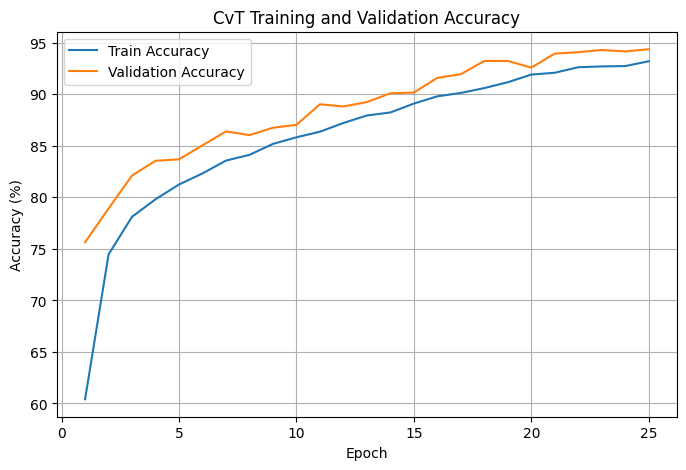

In [34]:
#accuracy plot
epochs_range = range(
    1,
    len(history["train_acc"]) + 1
)
plt.figure(figsize=(8, 5))
plt.plot(
    epochs_range,
    history["train_acc"],
    label="Train Accuracy"
)
plt.plot(
    epochs_range,
    history["val_acc"],
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel(
    "Accuracy (%)"
)
plt.title(
    "CvT Training and Validation Accuracy"
)
plt.legend()
plt.grid(True)
plt.show()

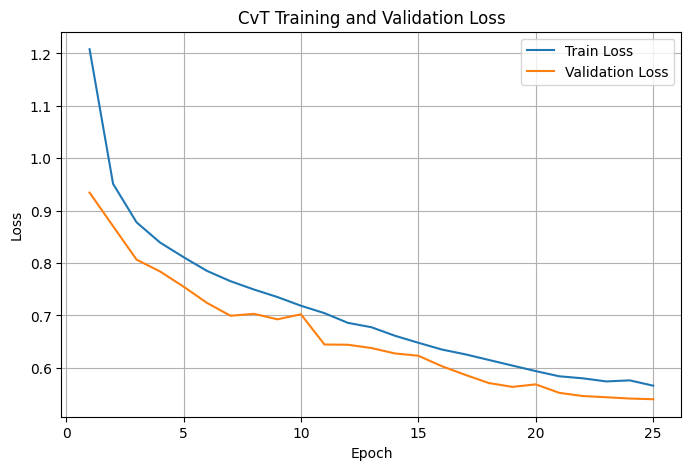

In [35]:
#plot the loss functions
plt.figure(figsize=(8, 5))
plt.plot(
    epochs_range,
    history["train_loss"],
    label="Train Loss"
)
plt.plot(
    epochs_range,
    history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "CvT Training and Validation Loss"
)
plt.legend()
plt.grid(True)
plt.show()

In [36]:
# evaluationg final epoch like Vit is not tuff so new method claude told
model.load_state_dict(
    torch.load(
        "best_cvt.pth",
        map_location=device
    )
)
print(
    "Best CvT checkpoint loaded."
)

Best CvT checkpoint loaded.


In [37]:
#final test accuracy 
test_loss, test_acc = evaluate(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device
)
print(
    f"Test Loss: "
    f"{test_loss:.4f}"
)
print(
    f"Test Accuracy: "
    f"{test_acc:.2f}%"
)

Test Loss: 0.6413
Test Accuracy: 89.37%


In [38]:
#detailed predictions for plotting confusion matrix later on
all_predictions = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(images)
        predictions = logits.argmax(
            dim=1
        )
        all_predictions.extend(
            predictions.cpu().numpy()
        )
        all_labels.extend(
            labels.numpy()
        )
all_predictions = np.array(
    all_predictions
)
all_labels = np.array(
    all_labels
)
print(
    "Predictions:",
    all_predictions.shape
)
print(
    "Labels:",
    all_labels.shape
)

Predictions: (3000,)
Labels: (3000,)


In [39]:
#form the classification report and confusion matrix
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)
class_names = (
    train_dataset_full.classes
)
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

   buildings     0.8935    0.8444    0.8682       437
      forest     0.9746    0.9726    0.9736       474
     glacier     0.8755    0.8264    0.8502       553
    mountain     0.8601    0.8667    0.8634       525
         sea     0.8941    0.9275    0.9105       510
      street     0.8727    0.9301    0.9005       501

    accuracy                         0.8937      3000
   macro avg     0.8951    0.8946    0.8944      3000
weighted avg     0.8938    0.8937    0.8933      3000



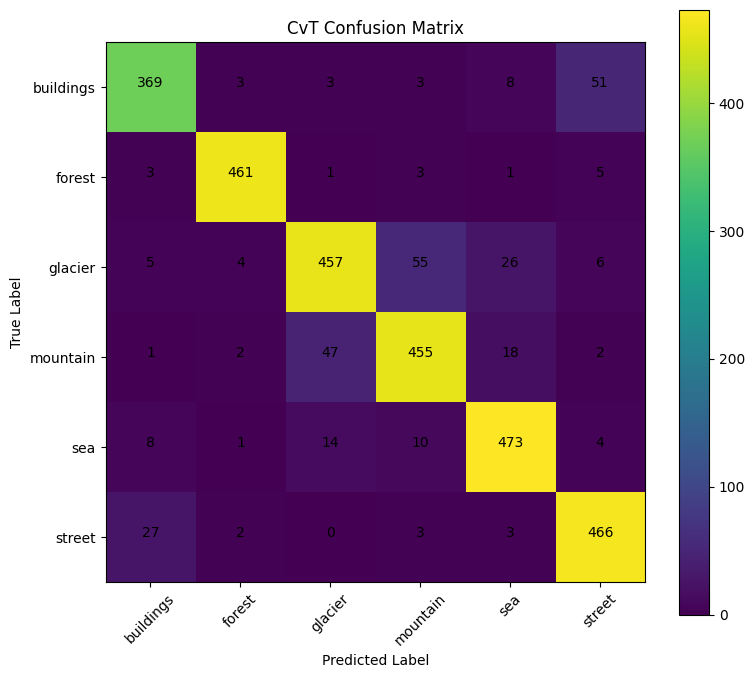

In [40]:
#plot the confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions
)
plt.figure(
    figsize=(8, 7)
)
plt.imshow(
    cm,
    interpolation="nearest"
)
plt.title(
    "CvT Confusion Matrix"
)
plt.colorbar()
tick_marks = np.arange(
    len(class_names)
)
plt.xticks(
    tick_marks,
    class_names,
    rotation=45
)
plt.yticks(
    tick_marks,
    class_names
)
threshold = (
    cm.max() / 2
)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            horizontalalignment="center"
        )
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

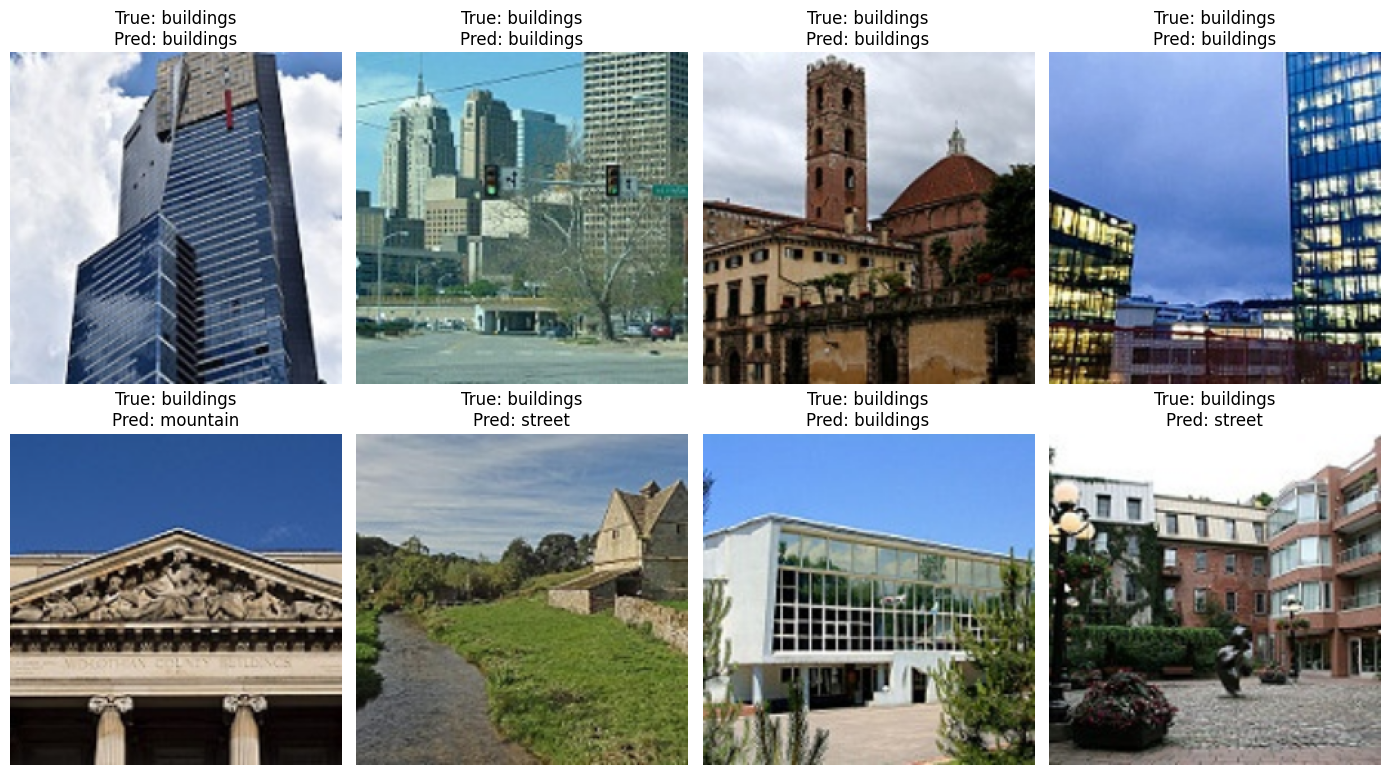

In [41]:
#FINALLLYY SHOW THE DAMN PREDICITONS
model.eval()
images, labels = next(
    iter(test_loader)
)
images_device = images.to(
    device
)
with torch.no_grad():
    logits = model(
        images_device
    )
    predictions = logits.argmax(
        dim=1
    ).cpu()
#help for reversing normalizations
mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)
std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)
def denormalize(image):
    image = (
        image * std
        + mean
    )
    return image.clamp(
        0,
        1
    )
#display the confusion matrix
plt.figure(
    figsize=(14, 8)
)
for i in range(8):
    plt.subplot(
        2,
        4,
        i + 1
    )
    image = denormalize(
        images[i].cpu()
    )
    image = image.permute(
        1,
        2,
        0
    )
    plt.imshow(image)
    true_name = class_names[
        labels[i]
    ]
    pred_name = class_names[
        predictions[i]
    ]
    plt.title(
        f"True: {true_name}\n"
        f"Pred: {pred_name}"
    )
    plt.axis("off")
plt.tight_layout()
plt.show()